In [1]:
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from decimal import *
import re
import seaborn as sns

In [2]:
file_path = '../data/mapbiomas_fire_tendencies_1985_2025.csv'

rows = []

with open(file_path, encoding='utf-8-sig') as f:
    for line in f:
        line = line.strip()

        line = line[1:-1]

        line = line.replace('""', '"')

        row = next(csv.reader([line]))
        rows.append(row)

fire_trends_df = pd.DataFrame(rows[1:], columns=rows[0])

fire_trends_df

fire_trends_df.columns = [
    'year',
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

fire_trends_df

,year,January,February,March,April,May,June,July,August,September,October,November,December
0,1985,127,501,-,432,1,39,618,115,120,25,198,-
1,1986,-,11,237,2,139,36,2,281,17,248,112,83
2,1987,-,626,1.166,645,240,18,321,481,934,-,38,"0,2"
3,1988,79,190,23,17,-,9,209,11,69,677,170,32
4,1989,-,-,90,2,157,18,73,175,80,1.718,10,543
5,1990,19,-,723,-,102,107,55,115,180,96,-,90
6,1991,"0,6",-,"0,2",478,106,53,1,19,38,2,156,"0,8"
7,1992,3,-,-,197,-,90,104,20,147,121,52,58
8,1993,237,5,2,-,98,9,114,53,96,"0,9",46,3
9,1994,4,26,25,8,2,9,58,64,59,795,121,18


In [3]:
def clean_fire_value(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip()

    if x in ['', '-']:
        return np.nan

    # Thousands:
    # 1.166 -> 1166
    if '.' in x:
        return float(x.replace('.', ''))

    # Decimal with comma:
    # 0,6 -> 0.6
    if ',' in x:
        return float(x.replace(',', '.'))

    return float(x)

month_columns = fire_trends_df.columns[1:]

for col in month_columns:
    fire_trends_df[col] = fire_trends_df[col].apply(clean_fire_value)

fire_trends_df['year'] = fire_trends_df['year'].astype(int)

fire_trends_df.fillna(0, inplace=True) 

fire_trends_df

,year,January,February,March,April,May,June,July,August,September,October,November,December
0,1985,127.0,501.0,0.0,432.0,1.0,39.0,618.0,115.0,120.0,25.0,198.0,0.0
1,1986,0.0,11.0,237.0,2.0,139.0,36.0,2.0,281.0,17.0,248.0,112.0,83.0
2,1987,0.0,626.0,1166.0,645.0,240.0,18.0,321.0,481.0,934.0,0.0,38.0,0.2
3,1988,79.0,190.0,23.0,17.0,0.0,9.0,209.0,11.0,69.0,677.0,170.0,32.0
4,1989,0.0,0.0,90.0,2.0,157.0,18.0,73.0,175.0,80.0,1718.0,10.0,543.0
5,1990,19.0,0.0,723.0,0.0,102.0,107.0,55.0,115.0,180.0,96.0,0.0,90.0
6,1991,0.6,0.0,0.2,478.0,106.0,53.0,1.0,19.0,38.0,2.0,156.0,0.8
7,1992,3.0,0.0,0.0,197.0,0.0,90.0,104.0,20.0,147.0,121.0,52.0,58.0
8,1993,237.0,5.0,2.0,0.0,98.0,9.0,114.0,53.0,96.0,0.9,46.0,3.0
9,1994,4.0,26.0,25.0,8.0,2.0,9.0,58.0,64.0,59.0,795.0,121.0,18.0


In [4]:
fire_trends_df_clean = fire_trends_df[fire_trends_df['year'].between(2016, 2024)].reset_index(drop=True)
fire_trends_df_clean

,year,January,February,March,April,May,June,July,August,September,October,November,December
0,2016,307.0,533.0,1376.0,345.0,12.0,280.0,1239.0,182.0,96.0,757.0,271.0,300.0
1,2017,0.8,10.0,0.3,0.1,25.0,4.0,13.0,89.0,4.0,113.0,59.0,16.0
2,2018,9.0,64.0,0.3,4.0,0.0,13.0,4.0,44.0,19.0,132.0,63.0,35.0
3,2019,16.0,0.9,19.0,0.0,0.1,1.0,5.0,60.0,19.0,18.0,108.0,98.0
4,2020,29.0,3.0,6.0,6.0,1.0,5.0,17.0,78.0,139.0,177.0,19.0,3.0
5,2021,0.3,0.0,16.0,6.0,20.0,3.0,52.0,100.0,75.0,26.0,179.0,0.0
6,2022,16.0,0.0,1.0,8.0,8.0,0.6,15.0,37.0,138.0,83.0,17.0,40.0
7,2023,23.0,0.0,1.0,1.0,2.0,6.0,2.0,151.0,345.0,334.0,35.0,85.0
8,2024,43.0,146.0,7.0,116.0,5.0,16.0,62.0,108.0,291.0,603.0,31.0,48.0


In [5]:
fire_trends_df_analysis = fire_trends_df_clean[fire_trends_df_clean['year'].between(2017, 2023)].reset_index(drop=True)
fire_trends_df_analysis

,year,January,February,March,April,May,June,July,August,September,October,November,December
0,2017,0.8,10.0,0.3,0.1,25.0,4.0,13.0,89.0,4.0,113.0,59.0,16.0
1,2018,9.0,64.0,0.3,4.0,0.0,13.0,4.0,44.0,19.0,132.0,63.0,35.0
2,2019,16.0,0.9,19.0,0.0,0.1,1.0,5.0,60.0,19.0,18.0,108.0,98.0
3,2020,29.0,3.0,6.0,6.0,1.0,5.0,17.0,78.0,139.0,177.0,19.0,3.0
4,2021,0.3,0.0,16.0,6.0,20.0,3.0,52.0,100.0,75.0,26.0,179.0,0.0
5,2022,16.0,0.0,1.0,8.0,8.0,0.6,15.0,37.0,138.0,83.0,17.0,40.0
6,2023,23.0,0.0,1.0,1.0,2.0,6.0,2.0,151.0,345.0,334.0,35.0,85.0


In [6]:
fire_trends_long_df = fire_trends_df_analysis.melt(
    id_vars='year',
    var_name='month',
    value_name='fire_trends (ha)'
)

month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

fire_trends_long_df['month'] = fire_trends_long_df['month'].map(month_map)

fire_trends_long_df['date'] = pd.to_datetime(
    fire_trends_long_df[['year', 'month']].assign(day=1)
).dt.strftime('%Y-%m')

fire_trends_long_df = fire_trends_long_df[
    ['date', 'year', 'month', 'fire_trends (ha)']
].sort_values(
    ['year', 'month']
).reset_index(drop=True)

fire_trends_long_df

,date,year,month,fire_trends (ha)
0,2017-01,2017,1,0.8
1,2017-02,2017,2,10.0
2,2017-03,2017,3,0.3
3,2017-04,2017,4,0.1
4,2017-05,2017,5,25.0
...,...,...,...,...
79,2023-08,2023,8,151.0
80,2023-09,2023,9,345.0
81,2023-10,2023,10,334.0
82,2023-11,2023,11,35.0


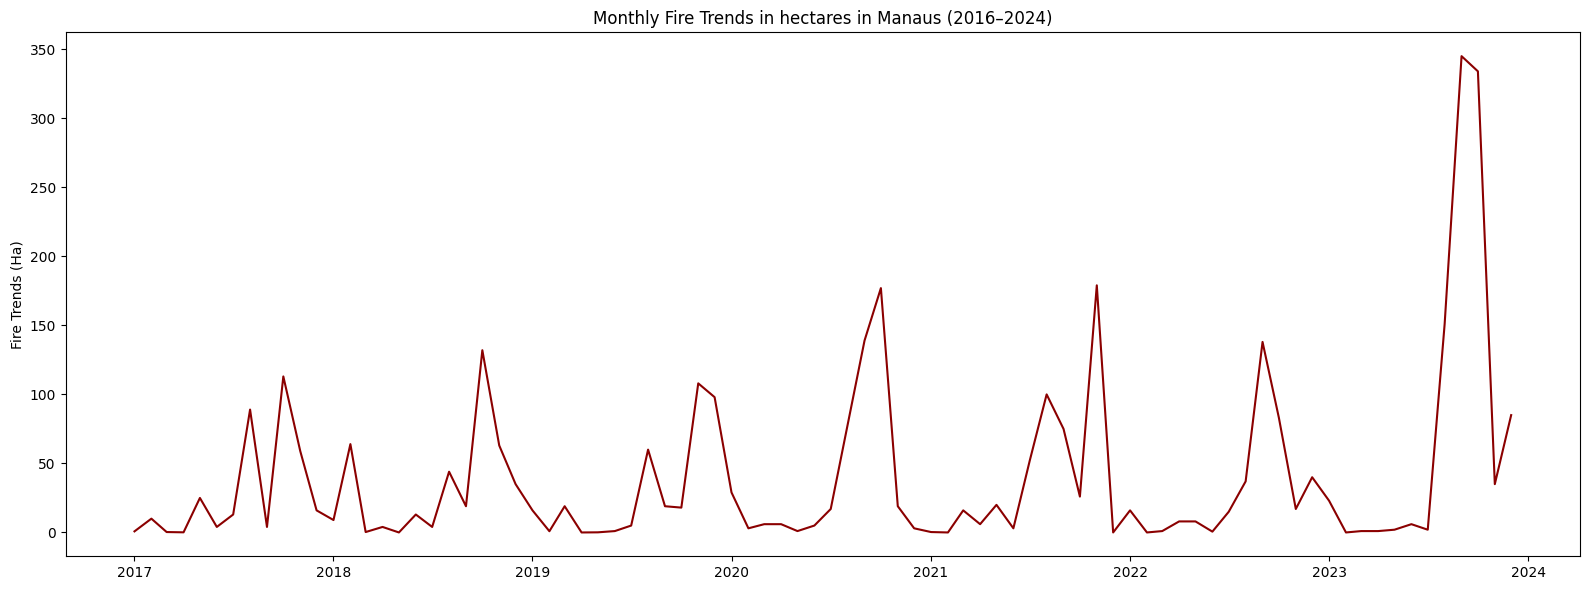

In [7]:
plot_df = fire_trends_long_df.copy()
plot_df['date_plot'] = pd.to_datetime(plot_df['date'])

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=plot_df,
    x='date_plot',
    y='fire_trends (ha)',
    color='darkred'
)

plt.title('Monthly Fire Trends in hectares in Manaus (2016–2024)')
plt.ylabel('Fire Trends (Ha)')
plt.xlabel('')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [8]:
# Saves the dataframe as a separate csv file to be used in different modules
fire_trends_long_df.to_csv("../data/mapbiomas_fire_trends_data_2017_2023.csv", index=False)

In [9]:
fire_trend_series = fire_trends_long_df.groupby('year')['fire_trends (ha)'].sum().sort_values(ascending=False)
fire_trend_series

year
2023    985.0
2020    483.0
2021    477.3
2018    387.3
2022    363.6
2019    345.0
2017    334.2
Name: fire_trends (ha), dtype: float64